# MBIS5023 A2 - AI-Assisted Improvement of a Breast Cancer CNN

**Student:** Ahmed Al Rafsan  
**Project:** Breast Cancer Wisconsin (Diagnostic) classification  
**Purpose:** Compare a basic A1-style CNN baseline with a more reliable and reproducible CNN pipeline.

This notebook records the technical changes used in the A2 process report. The model is an academic demonstration and is not a clinical diagnostic system.


## 1. Libraries and reproducibility

A fixed seed is used so that the data split, initial weights and training process can be reproduced as closely as possible.


In [1]:

from pathlib import Path
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)

try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

print("PyTorch:", torch.__version__)
print("Seed:", SEED)


PyTorch: 2.10.0+cpu
Seed: 2026


## 2. Load and inspect the dataset

The dataset contains numerical measurements calculated from breast mass images. The target is `diagnosis`, where M means malignant and B means benign.


In [2]:

possible_paths = [
    Path("../data/data.csv"),
    Path("data/data.csv"),
    Path("data.csv"),
    Path("/mnt/data/data.csv")
]
data_path = next((p for p in possible_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("Place data.csv in the repository data folder.")

raw_df = pd.read_csv(data_path)
print("Path:", data_path)
print("Shape:", raw_df.shape)
raw_df.head()


Path: ../data/data.csv
Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:

print("Missing values:", int(raw_df.isna().sum().sum()))
print("Duplicate rows:", int(raw_df.duplicated().sum()))
print("\nDiagnosis counts:")
print(raw_df["diagnosis"].value_counts())


Missing values: 569
Duplicate rows: 0

Diagnosis counts:
diagnosis
B    357
M    212
Name: count, dtype: int64


## 3. Clean and prepare the common dataset

The identifier and empty column are removed. The diagnosis is encoded as malignant = 1 and benign = 0.


In [4]:

drop_columns = [c for c in ["id", "Unnamed: 32"] if c in raw_df.columns]
df = raw_df.drop(columns=drop_columns).drop_duplicates().reset_index(drop=True)
df["target"] = df["diagnosis"].map({"M": 1, "B": 0})

feature_columns = [c for c in df.columns if c not in ["diagnosis", "target"]]
X = df[feature_columns].to_numpy(dtype=np.float32)
y = df["target"].to_numpy(dtype=np.float32)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

print("Predictors:", len(feature_columns))
print("Training/validation pool:", len(y_trainval))
print("Test records:", len(y_test))


Predictors: 30
Training/validation pool: 455
Test records: 114


## 4. Baseline model

The baseline represents a simple first-pass CNN:

- one convolution layer
- no feature standardisation
- no separate validation set
- no class weighting
- fixed training length
- accuracy-focused evaluation

This is useful as a starting point, but the raw features have very different scales and malignant recall is not explicitly prioritised.


In [5]:

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(8 * 30, 1)
        )

    def forward(self, x):
        return self.network(x)


torch.manual_seed(SEED)

X_baseline_train = torch.tensor(X_trainval).unsqueeze(1)
y_baseline_train = torch.tensor(y_trainval).unsqueeze(1)
X_baseline_test = torch.tensor(X_test).unsqueeze(1)

baseline_loader = DataLoader(
    TensorDataset(X_baseline_train, y_baseline_train),
    batch_size=32,
    shuffle=True
)

baseline_model = BaselineCNN()
baseline_loss = nn.BCEWithLogitsLoss()
baseline_optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=0.001
)

baseline_losses = []

for epoch in range(40):
    baseline_model.train()
    total_loss = 0.0

    for features, labels in baseline_loader:
        baseline_optimizer.zero_grad()
        logits = baseline_model(features)
        loss = baseline_loss(logits, labels)
        loss.backward()
        baseline_optimizer.step()
        total_loss += loss.item() * len(features)

    baseline_losses.append(
        total_loss / len(baseline_loader.dataset)
    )

baseline_model.eval()
with torch.no_grad():
    baseline_probabilities = (
        torch.sigmoid(baseline_model(X_baseline_test))
        .squeeze()
        .numpy()
    )

baseline_predictions = (
    baseline_probabilities >= 0.50
).astype(int)

print("Baseline training complete.")


Baseline training complete.


## 5. AI-assisted technical improvement plan

The improved pipeline addresses the baseline weaknesses by adding:

1. training-only standardisation to avoid data leakage
2. a separate stratified validation set
3. a deeper CNN with batch normalisation and dropout
4. class-weighted binary cross-entropy to give greater attention to malignant cases
5. Adam optimisation with weight decay
6. early stopping based on validation loss
7. accuracy, precision, recall, F1, specificity, ROC-AUC and confusion matrix


In [6]:

X_train, X_validation, y_train, y_validation = train_test_split(
    X_trainval,
    y_trainval,
    test_size=0.20,
    stratify=y_trainval,
    random_state=SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_validation_scaled = scaler.transform(X_validation).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

X_train_tensor = torch.tensor(X_train_scaled).unsqueeze(1)
X_validation_tensor = torch.tensor(X_validation_scaled).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled).unsqueeze(1)

y_train_tensor = torch.tensor(y_train).unsqueeze(1)
y_validation_tensor = torch.tensor(y_validation).unsqueeze(1)

improved_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=32,
    shuffle=True
)

print("Train:", X_train_tensor.shape)
print("Validation:", X_validation_tensor.shape)
print("Test:", X_test_tensor.shape)


Train: torch.Size([364, 1, 30])
Validation: torch.Size([91, 1, 30])
Test: torch.Size([114, 1, 30])


In [7]:

class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(64 * 15, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.network(x)


torch.manual_seed(SEED)
improved_model = ImprovedCNN()

benign_count = int((y_train == 0).sum())
malignant_count = int((y_train == 1).sum())
positive_weight = torch.tensor(
    [benign_count / malignant_count],
    dtype=torch.float32
)

improved_loss = nn.BCEWithLogitsLoss(
    pos_weight=positive_weight
)

improved_optimizer = torch.optim.Adam(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)

print(improved_model)
print("\nPositive-class weight:", round(float(positive_weight.item()), 3))


ImprovedCNN(
  (network): Sequential(
    (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=960, out_features=64, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.2, inplace=False)
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)

Positive-class weight: 1.676


In [8]:

maximum_epochs = 200
patience = 25
best_validation_loss = float("inf")
best_state = None
epochs_without_improvement = 0

training_losses = []
validation_losses = []

for epoch in range(maximum_epochs):
    improved_model.train()
    total_training_loss = 0.0

    for features, labels in improved_loader:
        improved_optimizer.zero_grad()
        logits = improved_model(features)
        loss = improved_loss(logits, labels)
        loss.backward()
        improved_optimizer.step()
        total_training_loss += loss.item() * len(features)

    average_training_loss = (
        total_training_loss / len(improved_loader.dataset)
    )

    improved_model.eval()
    with torch.no_grad():
        validation_logits = improved_model(X_validation_tensor)
        average_validation_loss = improved_loss(
            validation_logits,
            y_validation_tensor
        ).item()

    training_losses.append(average_training_loss)
    validation_losses.append(average_validation_loss)

    if average_validation_loss < best_validation_loss - 1e-5:
        best_validation_loss = average_validation_loss
        best_state = {
            name: value.detach().clone()
            for name, value in improved_model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping at epoch", epoch + 1)
        break

improved_model.load_state_dict(best_state)

print("Completed epochs:", len(training_losses))
print("Best validation loss:", round(best_validation_loss, 4))


Early stopping at epoch 27
Completed epochs: 27
Best validation loss: 0.1999


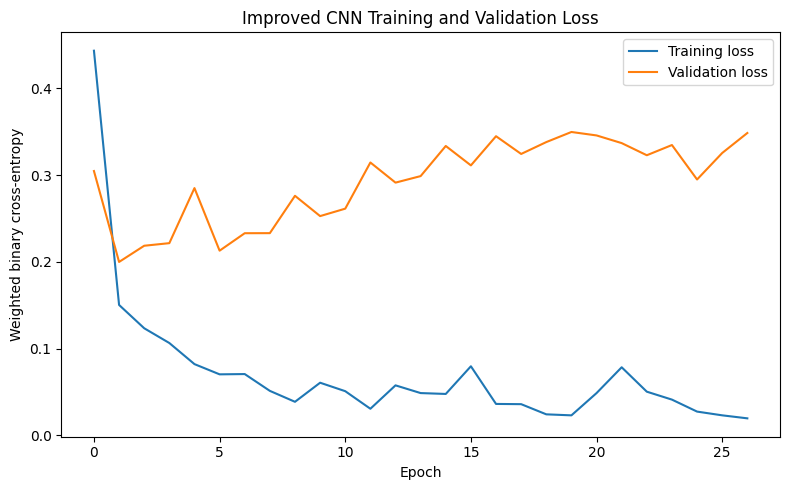

In [9]:

plt.figure(figsize=(8, 5))
plt.plot(training_losses, label="Training loss")
plt.plot(validation_losses, label="Validation loss")
plt.title("Improved CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Weighted binary cross-entropy")
plt.legend()
plt.tight_layout()
plt.savefig("../results/improved_training_validation_loss.png", dpi=180)
plt.show()


## 6. Evaluation and comparison

The same untouched test set is used for both models. Malignant is the positive class.


In [10]:

improved_model.eval()
with torch.no_grad():
    improved_probabilities = (
        torch.sigmoid(improved_model(X_test_tensor))
        .squeeze()
        .numpy()
    )

improved_predictions = (
    improved_probabilities >= 0.50
).astype(int)


def metric_row(name, true_values, predictions, probabilities):
    matrix = confusion_matrix(true_values, predictions)
    tn, fp, fn, tp = matrix.ravel()
    specificity = tn / (tn + fp)

    return {
        "Model": name,
        "Accuracy": accuracy_score(true_values, predictions),
        "Precision": precision_score(true_values, predictions),
        "Recall": recall_score(true_values, predictions),
        "F1": f1_score(true_values, predictions),
        "Specificity": specificity,
        "ROC-AUC": roc_auc_score(true_values, probabilities),
        "False negatives": int(fn),
        "False positives": int(fp)
    }


comparison = pd.DataFrame([
    metric_row(
        "Baseline CNN",
        y_test,
        baseline_predictions,
        baseline_probabilities
    ),
    metric_row(
        "Improved CNN",
        y_test,
        improved_predictions,
        improved_probabilities
    )
])

comparison.round(4)


,Model,Accuracy,Precision,Recall,F1,Specificity,ROC-AUC,False negatives,False positives
0,Baseline CNN,0.9211,0.9714,0.8095,0.8831,0.9861,0.9669,8,1
1,Improved CNN,0.9649,0.9524,0.9524,0.9524,0.9722,0.9964,2,2


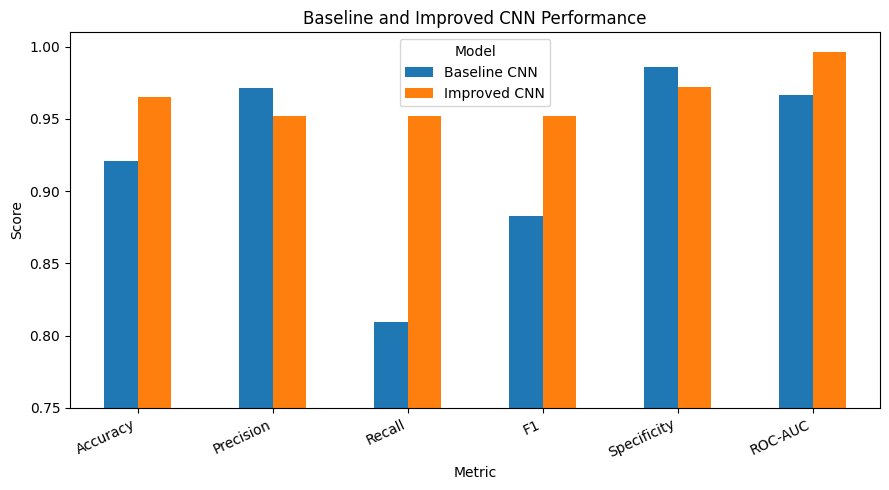

In [11]:

comparison.to_csv(
    "../results/model_metrics_comparison.csv",
    index=False
)

metric_columns = [
    "Accuracy", "Precision", "Recall",
    "F1", "Specificity", "ROC-AUC"
]

plot_data = comparison.set_index("Model")[metric_columns].T

plt.figure(figsize=(9, 5))
plot_data.plot(kind="bar", ax=plt.gca())
plt.ylim(0.75, 1.01)
plt.title("Baseline and Improved CNN Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("../results/model_metrics_comparison.png", dpi=180)
plt.show()


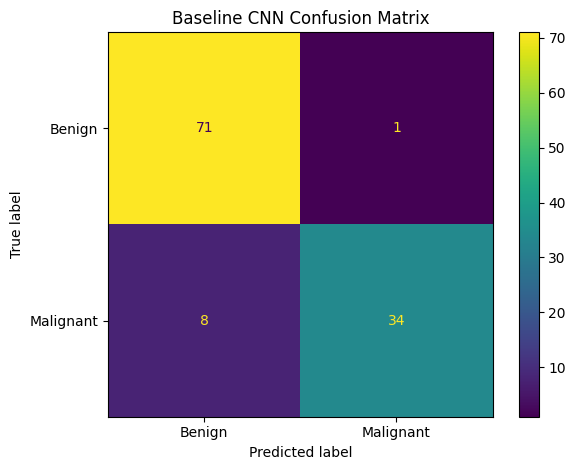

In [12]:

baseline_matrix = confusion_matrix(
    y_test,
    baseline_predictions
)

baseline_display = ConfusionMatrixDisplay(
    confusion_matrix=baseline_matrix,
    display_labels=["Benign", "Malignant"]
)
baseline_display.plot()
plt.title("Baseline CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/baseline_confusion_matrix.png", dpi=180)
plt.show()


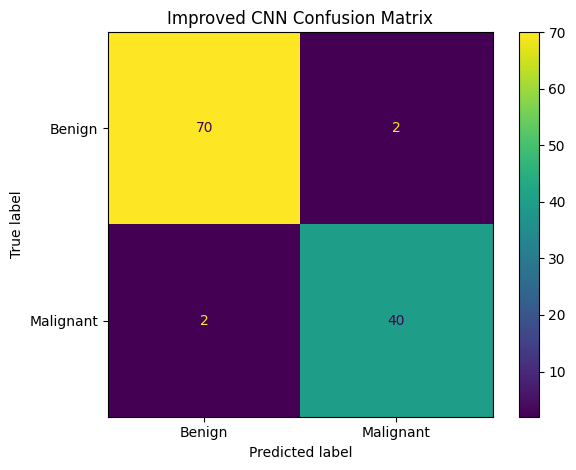

In [13]:

improved_matrix = confusion_matrix(
    y_test,
    improved_predictions
)

improved_display = ConfusionMatrixDisplay(
    confusion_matrix=improved_matrix,
    display_labels=["Benign", "Malignant"]
)
improved_display.plot()
plt.title("Improved CNN Confusion Matrix")
plt.tight_layout()
plt.savefig("../results/improved_confusion_matrix.png", dpi=180)
plt.show()


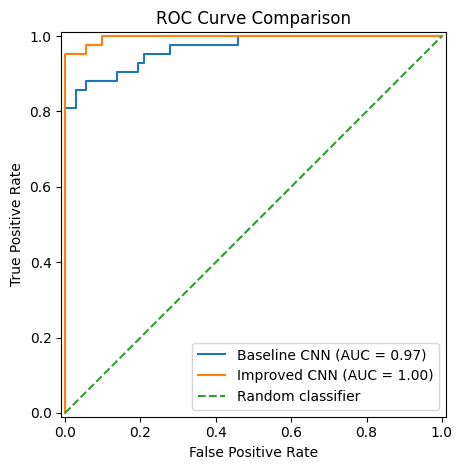

In [14]:

RocCurveDisplay.from_predictions(
    y_test,
    baseline_probabilities,
    name="Baseline CNN"
)
RocCurveDisplay.from_predictions(
    y_test,
    improved_probabilities,
    name="Improved CNN",
    ax=plt.gca()
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("../results/roc_curve_comparison.png", dpi=180)
plt.show()


In [15]:

print("Improved CNN classification report:\n")
print(classification_report(
    y_test,
    improved_predictions,
    target_names=["Benign", "Malignant"],
    digits=4
))


Improved CNN classification report:

              precision    recall  f1-score   support

      Benign     0.9722    0.9722    0.9722        72
   Malignant     0.9524    0.9524    0.9524        42

    accuracy                         0.9649       114
   macro avg     0.9623    0.9623    0.9623       114
weighted avg     0.9649    0.9649    0.9649       114



## 7. Interpretation

The improved pipeline reduced malignant false negatives from eight to two. Malignant recall increased from about 0.81 to about 0.95, while overall accuracy increased from about 0.92 to about 0.96. This improvement is important for the project objective because false negatives represent malignant cases incorrectly classified as benign.

The final ROC-AUC is also very high, showing strong separation between the two classes across decision thresholds. However, the dataset is small and the features are tabular measurements rather than raw images. The CNN is therefore suitable for this portfolio requirement, but the result should not be treated as clinical evidence.


## 8. Reproducibility notes

- Keep `data.csv` in the repository `data` folder.
- Install the packages listed in `requirements.txt`.
- Run the notebook from top to bottom.
- The seed is fixed at 2026.
- The scaler is fitted only on training data.
- The test set is held back until final evaluation.
